# HandWriteAI — EMNIST Balanced Character Recognition

## Objective

The goal of this project is to build a CNN-based handwritten character recognition system using the EMNIST Balanced dataset.

The trained CNN recognizes 47 character classes including:

- Digits
- Uppercase letters
- Selected lowercase letters

The trained model is later used by a FastAPI backend for real-time image prediction.

## Image preprocessing convention

The raw EMNIST CSV representation is converted from 784 pixels into a 28×28 image.

For visualization and training, the image is transposed:

```python
np.transpose(image, (0, 2, 1))

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import warnings
import os

warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Dropout,BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
emnist_train_file = pd.read_csv("../dataset/emnist/emnist-balanced-train.csv")
emnist_test_file = pd.read_csv("../dataset/emnist/emnist-balanced-test.csv")

In [3]:
emnist_test_file.head()

,41,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.523,0.524,0.525,0.526,0.527,0.528,0.529,0.530,0.531,0.532
0,39,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,26,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,44,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,33,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
emnist_train_file.head()

,45,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.524,0.525,0.526,0.527,0.528,0.529,0.530,0.531,0.532,0.533
0,36,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,43,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,15,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,42,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
print(emnist_train_file.columns)

Index(['45', '0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8',
       ...
       '0.524', '0.525', '0.526', '0.527', '0.528', '0.529', '0.530', '0.531',
       '0.532', '0.533'],
      dtype='str', length=785)


In [6]:
emnist_test_file.columns

Index(['41', '0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8',
       ...
       '0.523', '0.524', '0.525', '0.526', '0.527', '0.528', '0.529', '0.530',
       '0.531', '0.532'],
      dtype='str', length=785)

In [7]:
print("Train shape:", emnist_train_file.shape)
print("Test shape :", emnist_test_file.shape)

Train shape: (112799, 785)
Test shape : (18799, 785)


In [8]:
emnist_test_file.info()

<class 'pandas.DataFrame'>
RangeIndex: 18799 entries, 0 to 18798
Columns: 785 entries, 41 to 0.532
dtypes: int64(785)
memory usage: 112.6 MB


In [9]:
emnist_test_file.isnull().sum()

41       0
0        0
0.1      0
0.2      0
0.3      0
        ..
0.528    0
0.529    0
0.530    0
0.531    0
0.532    0
Length: 785, dtype: int64

In [10]:
print("Train classes:", emnist_train_file.iloc[:, 0].nunique())
print("Test classes :", emnist_test_file.iloc[:, 0].nunique())

Train classes: 47
Test classes : 47


In [11]:
emnist_test_file.columns = (
    ["labels"] +
    [f"{i}x{j}" for i in range(1, 29) for j in range(1, 29)]
)

print(emnist_test_file.shape)
display(emnist_test_file.head())

(18799, 785)


,labels,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,39,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,26,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,44,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,33,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
print(emnist_test_file.columns[:10])
print(emnist_test_file.columns[-10:])

Index(['labels', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8',
       '1x9'],
      dtype='str')
Index(['28x19', '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26',
       '28x27', '28x28'],
      dtype='str')


In [13]:
emnist_test_file.isnull().sum()

labels    0
1x1       0
1x2       0
1x3       0
1x4       0
         ..
28x24     0
28x25     0
28x26     0
28x27     0
28x28     0
Length: 785, dtype: int64

In [14]:
emnist_train_file.columns = (
    ["labels"] +
    [f"{i}x{j}" for i in range(1, 29) for j in range(1, 29)]
)

print(emnist_train_file.shape)
display(emnist_train_file.head())

(112799, 785)


,labels,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,36,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,43,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,15,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,42,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [15]:
X_train = emnist_train_file.drop("labels" , axis=1).values
y_train = emnist_train_file["labels"].values
X_test = emnist_test_file.drop("labels" , axis=1).values
y_test = emnist_test_file["labels"].values

In [16]:
X_train = X_train.astype("float32")/255.0
X_test = X_test.astype("float32")/255.0 

In [17]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (112799, 784)
y_train: (112799,)
X_test : (18799, 784)
y_test : (18799,)


# Convert 784 pixels into 28×28 images

In [18]:
X_train_img = X_train.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)

# Correct orientation for this EMNIST CSV representation


In [19]:
X_train_img = np.transpose(X_train_img,(0, 2, 1))
X_test_img = np.transpose(X_test_img,(0, 2, 1))

# Add channel dimension for CNN

In [20]:
X_train_cnn = X_train_img[..., np.newaxis]
X_test_cnn = X_test_img[..., np.newaxis]

In [21]:
print("CNN train shape:",X_train_cnn.shape)
print("CNN test shape:",X_test_cnn.shape)

CNN train shape: (112799, 28, 28, 1)
CNN test shape: (18799, 28, 28, 1)


## Visual Check

Before training the CNN, verify that the EMNIST characters appear upright and readable.

If the characters are correctly oriented, do not add another rotation or flip.

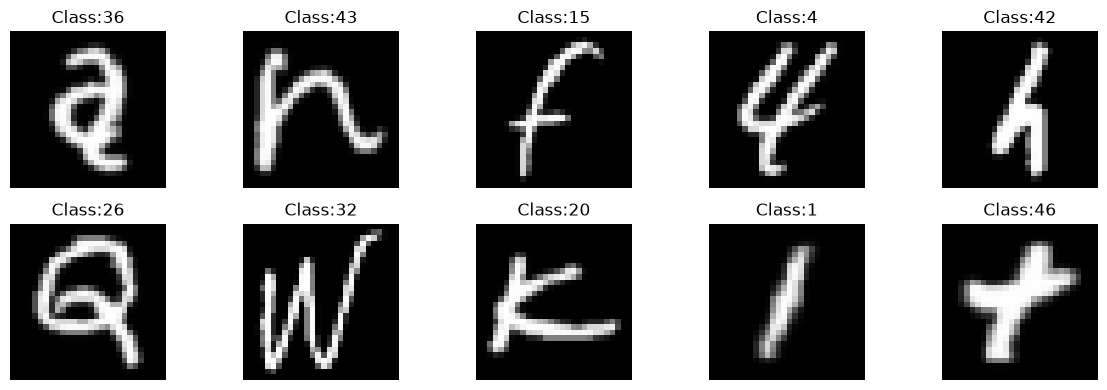

In [22]:
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_img[i],cmap="gray")
    plt.title(f"Class:{y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [23]:
class_mapping = {
    0: "0",
    1: "1",
    2: "2",
    3: "3",
    4: "4",
    5: "5",
    6: "6",
    7: "7",
    8: "8",
    9: "9",

    10: "A",
    11: "B",
    12: "C",
    13: "D",
    14: "E",
    15: "F",
    16: "G",
    17: "H",
    18: "I",
    19: "J",
    20: "K",
    21: "L",
    22: "M",
    23: "N",
    24: "O",
    25: "P",
    26: "Q",
    27: "R",
    28: "S",
    29: "T",
    30: "U",
    31: "V",
    32: "W",
    33: "X",
    34: "Y",
    35: "Z",

    36: "a",
    37: "b",
    38: "d",
    39: "e",
    40: "f",
    41: "g",
    42: "h",
    43: "n",
    44: "q",
    45: "r",
    46: "t"
}

print("Number of classes:", len(class_mapping))

print(
    "Example:",
    class_mapping[10],
    class_mapping[20],
    class_mapping[35],
    class_mapping[46]
)

Number of classes: 47
Example: A K Z t


## Train / Validation Split

The official EMNIST test set is kept untouched.

A 10% validation set is created from the training data.

This validation set is used during training for EarlyStopping and model checkpointing.

In [24]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_cnn,
    y_train,
    test_size=0.10,
    random_state=42,
    stratify=y_train
)

print("Training:", X_tr.shape)
print("Validation:", X_val.shape)
print("Test:", X_test_cnn.shape)

Training: (101519, 28, 28, 1)
Validation: (11280, 28, 28, 1)
Test: (18799, 28, 28, 1)


In [25]:
cnn = Sequential([
    Conv2D(32,kernel_size=(3, 3),activation="relu",input_shape=(28, 28, 1)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64,kernel_size=(3, 3),activation="relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(47, activation="softmax")
])

In [30]:
cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 26, 26, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 11, 11, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 47)                  │           6,063 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 230,191 (899.18 KB)

 Trainable params: 229,999 (898.43 KB)

 Non-trainable params: 192 (768.00 B)

In [31]:
os.makedirs("../model",exist_ok=True)
callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "../model/emnist_cnn_best.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

In [37]:
history = cnn.fit(
    X_tr,
    y_tr,
    epochs=20,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 102s 128ms/step - accuracy: 0.8834 - loss: 0.3155 - val_accuracy: 0.8779 - val_loss: 0.3662
Epoch 2/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 94s 118ms/step - accuracy: 0.8845 - loss: 0.3064 - val_accuracy: 0.8735 - val_loss: 0.3670
Epoch 3/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 138s 113ms/step - accuracy: 0.8861 - loss: 0.3022 - val_accuracy: 0.8810 - val_loss: 0.3625
Epoch 4/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 98s 123ms/step - accuracy: 0.8869 - loss: 0.2988 - val_accuracy: 0.8781 - val_loss: 0.3642
Epoch 5/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 135s 114ms/step - accuracy: 0.8906 - loss: 0.2872 - val_accuracy: 0.8773 - val_loss: 0.3706
Epoch 6/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 98s 124ms/step - accuracy: 0.8917 - loss: 0.2839 - val_accuracy: 0.8785 - val_loss: 0.3877


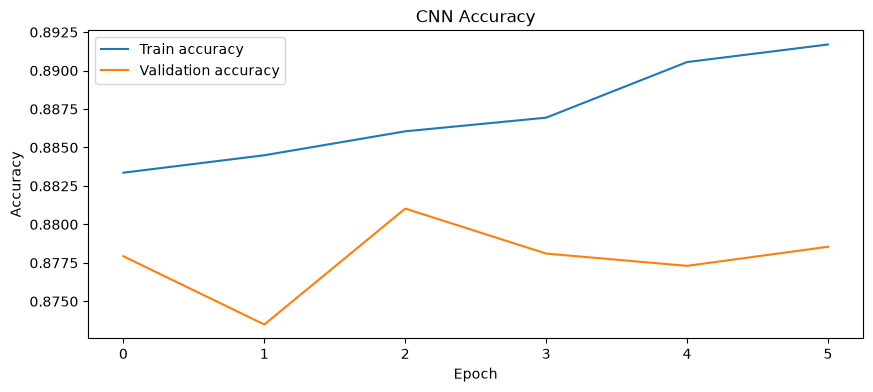

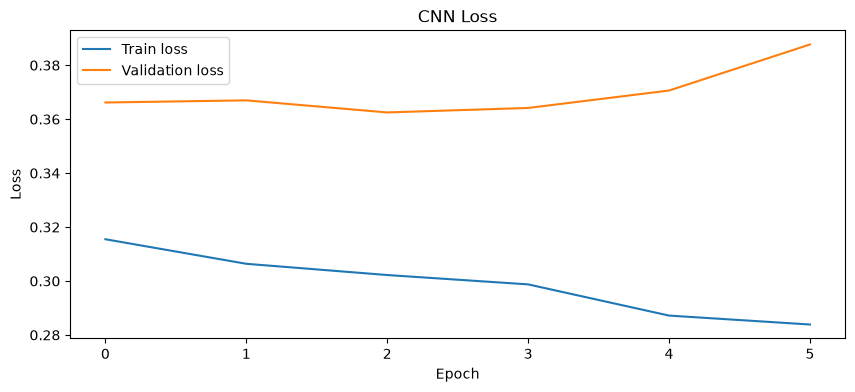

In [38]:
plt.figure(figsize=(10, 4))
plt.plot(
    history.history["accuracy"],
    label="Train accuracy"
)
plt.plot(
    history.history["val_accuracy"],
    label="Validation accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(
    history.history["loss"],
    label="Train loss"
)
plt.plot(
    history.history["val_loss"],
    label="Validation loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss")
plt.legend()
plt.show()

In [39]:
test_loss, test_accuracy = cnn.evaluate(
    X_test_cnn,
    y_test,
    verbose=1
)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

588/588 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8786 - loss: 0.3834
Test loss: 0.3834
Test accuracy: 0.8786
Test accuracy: 87.86%


In [41]:
y_prob = cnn.predict(
    X_test_cnn,
    batch_size=256,
    verbose=1
)

y_pred = np.argmax(
    y_prob,
    axis=1
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            class_mapping[i]
            for i in range(47)
        ],
        digits=4,
        zero_division=0
    )
)

74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step
Macro F1: 0.8777
Weighted F1: 0.8778
              precision    recall  f1-score   support

           0     0.6708    0.6775    0.6741       400
           1     0.5467    0.7900    0.6462       400
           2     0.9264    0.8500    0.8866       400
           3     0.9899    0.9800    0.9849       400
           4     0.9449    0.9000    0.9219       400
           5     0.9413    0.8825    0.9110       400
           6     0.9322    0.9275    0.9298       400
           7     0.9633    0.9850    0.9740       400
           8     0.9236    0.9375    0.9305       400
           9     0.7050    0.7350    0.7197       400
           A     0.9747    0.9650    0.9698       400
           B     0.9578    0.9650    0.9614       400
           C     0.9644    0.9475    0.9559       400
           D     0.9242    0.9150    0.9196       400
           E     0.9873    0.9750    0.9811       400
           F     0.6214    0.6525    0.6366       400
    

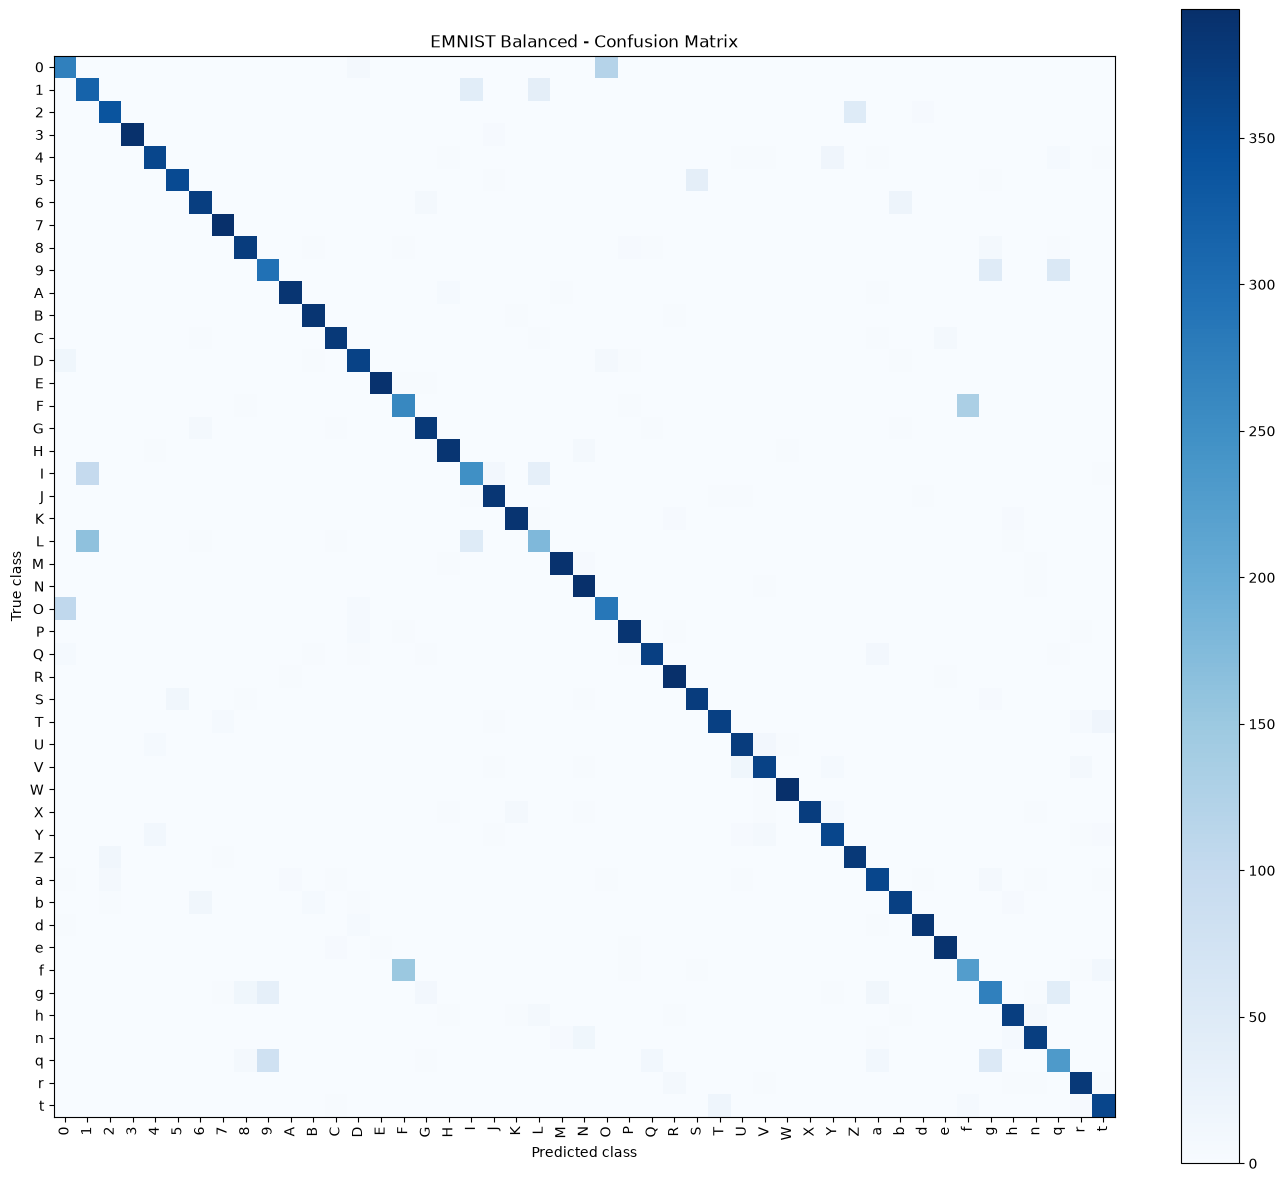

In [42]:
cm = confusion_matrix(
    y_test,
    y_pred
)
plt.figure(figsize=(14, 12))
plt.imshow(
    cm,
    cmap="Blues"
)
plt.colorbar()
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("EMNIST Balanced - Confusion Matrix")
plt.xticks(
    range(47),
    [class_mapping[i]
        for i in range(47)
    ],
    rotation=90
)

plt.yticks(
    range(47),
    [
        class_mapping[i]
        for i in range(47)
    ]
)
plt.tight_layout()
plt.show()

In [43]:
for i in range(10):
    p = cnn.predict(
        X_test_cnn[i:i+1],
        verbose=0
    )[0]

    pred_class = int(
        np.argmax(p)
    )

    print(
        f"True: {y_test[i]} "
        f"({class_mapping[y_test[i]]}) | "
        f"Pred: {pred_class} "
        f"({class_mapping[pred_class]}) | "
        f"Confidence: "
        f"{p[pred_class] * 100:.2f}%"
    )

True: 39 (e) | Pred: 39 (e) | Confidence: 99.99%
True: 9 (9) | Pred: 9 (9) | Confidence: 59.80%
True: 26 (Q) | Pred: 26 (Q) | Confidence: 100.00%
True: 44 (q) | Pred: 44 (q) | Confidence: 46.09%
True: 33 (X) | Pred: 33 (X) | Confidence: 100.00%
True: 14 (E) | Pred: 14 (E) | Confidence: 100.00%
True: 11 (B) | Pred: 11 (B) | Confidence: 89.49%
True: 3 (3) | Pred: 3 (3) | Confidence: 99.94%
True: 12 (C) | Pred: 12 (C) | Confidence: 80.65%
True: 16 (G) | Pred: 16 (G) | Confidence: 99.92%


In [44]:
z_indices = np.where(
    y_test == 35
)[0]
print("Number of Z samples:",len(z_indices))

for i in z_indices[:10]:
    p = cnn.predict(
        X_test_cnn[i:i+1],
        verbose=0
    )[0]
    pred_class = int(
        np.argmax(p)
    )
    print(
        f"True: Z | "
        f"Pred: {class_mapping[pred_class]} | "
        f"Confidence: "
        f"{p[pred_class] * 100:.2f}%"
    )

Number of Z samples: 400
True: Z | Pred: Z | Confidence: 99.80%
True: Z | Pred: Z | Confidence: 100.00%
True: Z | Pred: Z | Confidence: 99.83%
True: Z | Pred: Z | Confidence: 81.63%
True: Z | Pred: Z | Confidence: 100.00%
True: Z | Pred: Z | Confidence: 99.94%
True: Z | Pred: Z | Confidence: 99.96%
True: Z | Pred: Z | Confidence: 100.00%
True: Z | Pred: Z | Confidence: 99.50%
True: Z | Pred: Z | Confidence: 97.57%


In [47]:
cnn.save("../model/emnist_cnn.keras")
print("Saved:",os.path.abspath("../model/emnist_cnn.keras"))
print("Exists:",os.path.exists("../model/emnist_cnn.keras"))

Saved: D:\HandWriteAI\model\emnist_cnn.keras
Exists: True


## Model Deployment

The trained CNN model is saved as:

`../model/emnist_cnn.keras`

The FastAPI backend loads this model and performs the following pipeline:

Camera/Image
→ Grayscale
→ Binary Threshold
→ Character Detection
→ Crop
→ Resize
→ Center on 28×28 canvas
→ Stroke enhancement
→ Normalization
→ CNN Prediction
→ Class Mapping
→ Character + Confidence

The backend does not apply rotation or flipping because the model was trained using the corrected EMNIST transpose convention.